# Bài 1 - Hồi quy tuyến tính

**Học phần:** Học máy ứng dụng  
**Mã lớp học phần:** 261_71ITAI41203_0101  
**Sinh viên:** Trần An Kỳ  
**MSSV:** 2474802010460  
**Khóa:** 30 - Sinh viên năm 3

Notebook được tổng hợp trực tiếp từ:

- `Lab01_Hoi_quy_tuyen_tinh.pdf`
- `data/gia_nha.csv`
- 7 tệp mã nguồn trong thư mục `code`

Phần A giữ nguyên mã nguồn mẫu của folder. Phần B giải 6 bài tập cuối tài liệu.

## Chuẩn bị

Cell này xác định thư mục gốc của bài. Nhờ đó notebook có thể chạy khi được mở từ
`bai01_hoi_quy` hoặc từ thư mục môn học `Mayhoc`.

In [1]:
from pathlib import Path
import os

thu_muc_hien_tai = Path.cwd()
if (thu_muc_hien_tai / "data" / "gia_nha.csv").exists():
    thu_muc_bai = thu_muc_hien_tai
elif (thu_muc_hien_tai / "bai01_hoi_quy" / "data" / "gia_nha.csv").exists():
    thu_muc_bai = thu_muc_hien_tai / "bai01_hoi_quy"
else:
    raise FileNotFoundError("Không tìm thấy data/gia_nha.csv")

os.chdir(thu_muc_bai)
print("Thư mục chạy notebook:", Path.cwd())

Thư mục chạy notebook: D:\Nam3_ki1\Mayhoc\bai01_hoi_quy


## Phần A - Bảy bước thực hành trong folder

### Bước 1 - Đọc dữ liệu

Nguồn: `code/b1_doc_du_lieu.py`

In [2]:
# -*- coding: utf-8 -*-
"""Bước 1: đọc tệp dữ liệu và nhìn qua một lượt.
Chú thích trong tệp viết tiếng Việt có dấu, nhưng phần in ra màn hình cố ý
viết không dấu. Cửa sổ lệnh Windows thường không hiện được chữ có dấu.
"""

import pandas as pd

# Đọc tệp CSV thành một bảng. Tên df là viết tắt quen dùng của data frame.
df = pd.read_csv("data/gia_nha.csv")

print("Kich thuoc bang (so dong, so cot):", df.shape)
print()

print("Nam dong dau tien:")
print(df.head())
print()

print("Ten cac cot:", list(df.columns))
print()

print("Thong ke nhanh cot dien_tich va cot gia:")
print(df[["dien_tich", "gia"]].describe().round(2))
print()

print("So o bi thieu trong tung cot:")
print(df.isna().sum())

Kich thuoc bang (so dong, so cot): (60, 4)

Nam dong dau tien:
   dien_tich  so_phong  tuoi_nha   gia
0       35.5         1        18  3.00
1       37.6         2         7  3.87
2       49.4         2        20  4.25
3       49.0         2        16  4.60
4       49.9         1        12  3.99

Ten cac cot: ['dien_tich', 'so_phong', 'tuoi_nha', 'gia']

Thong ke nhanh cot dien_tich va cot gia:
       dien_tich    gia
count      60.00  60.00
mean       77.73   6.49
std        20.22   1.64
min        35.50   3.00
25%        63.02   5.16
50%        75.10   6.40
75%        91.88   7.70
max       117.50   9.74

So o bi thieu trong tung cot:
dien_tich    0
so_phong     0
tuoi_nha     0
gia          0
dtype: int64


### Bước 2 - Đo sai số

Nguồn: `code/b2_do_sai_so.py`

In [3]:
# -*- coding: utf-8 -*-
"""Bước 2: đo xem một đường thẳng dự đoán sai bao nhiêu.

Chỉ lấy 5 căn cho dễ nhìn. Thử hai đường thẳng khác nhau rồi so sai số
trung bình bình phương của từng đường.
"""

import pandas as pd

df = pd.read_csv("data/gia_nha.csv")

# Lấy 5 căn trải đều từ nhỏ nhất tới lớn nhất, không lấy 5 căn đầu bảng
# vì chúng có diện tích gần bằng nhau nên nhìn không rõ.
nho = df.iloc[[0, 14, 29, 44, 59]]

x = nho["dien_tich"].to_numpy()
y = nho["gia"].to_numpy()


def mse(w, b):
    """Sai số trung bình bình phương của đường thẳng y = w*x + b."""
    y_du_doan = w * x + b
    sai_so = y - y_du_doan
    return (sai_so**2).mean()


print("Nam can duoc chon:")
for i in range(5):
    print(f"  {x[i]:6.1f} m2  ->  {y[i]:5.2f} ty")
print()

for w, b in [(0.05, 1.5), (0.08, 0.5)]:
    print(f"Duong thang y = {w} * x + {b}")
    for i in range(5):
        du_doan = w * x[i] + b
        sai_so = y[i] - du_doan
        print(
            f"  x = {x[i]:6.1f}  that = {y[i]:5.2f}"
            f"  du doan = {du_doan:5.2f}  sai so = {sai_so:+6.2f}"
        )
    print(f"  MSE = {mse(w, b):.4f}")
    print()

print("Duong nao co MSE nho hon thi duong do khop du lieu tot hon.")

Nam can duoc chon:
    35.5 m2  ->   3.00 ty
    61.3 m2  ->   4.56 ty
    74.2 m2  ->   7.17 ty
    91.3 m2  ->   7.83 ty
   115.9 m2  ->   9.01 ty

Duong thang y = 0.05 * x + 1.5
  x =   35.5  that =  3.00  du doan =  3.28  sai so =  -0.28
  x =   61.3  that =  4.56  du doan =  4.56  sai so =  -0.00
  x =   74.2  that =  7.17  du doan =  5.21  sai so =  +1.96
  x =   91.3  that =  7.83  du doan =  6.07  sai so =  +1.76
  x =  115.9  that =  9.01  du doan =  7.30  sai so =  +1.71
  MSE = 1.9947

Duong thang y = 0.08 * x + 0.5
  x =   35.5  that =  3.00  du doan =  3.34  sai so =  -0.34
  x =   61.3  that =  4.56  du doan =  5.40  sai so =  -0.84
  x =   74.2  that =  7.17  du doan =  6.44  sai so =  +0.73
  x =   91.3  that =  7.83  du doan =  7.80  sai so =  +0.03
  x =  115.9  that =  9.01  du doan =  9.77  sai so =  -0.76
  MSE = 0.3896

Duong nao co MSE nho hon thi duong do khop du lieu tot hon.


### Bước 3 - Tìm hệ số bằng công thức

Nguồn: `code/b3_cong_thuc.py`

In [4]:
# -*- coding: utf-8 -*-
"""Bước 3: tìm w và b tốt nhất bằng công thức, không cần thư viện."""

import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()

# Công thức bình phương tối thiểu cho đường thẳng một biến
tu_so = ((x - x_tb) * (y - y_tb)).sum()
mau_so = ((x - x_tb) ** 2).sum()

w = tu_so / mau_so
b = y_tb - w * x_tb

print(f"Trung binh dien tich : {x_tb:.4f}")
print(f"Trung binh gia       : {y_tb:.4f}")
print(f"Tu so                 : {tu_so:.4f}")
print(f"Mau so                : {mau_so:.4f}")
print()
print(f"He so goc      w = {w:.6f}")
print(f"He so chan     b = {b:.6f}")
print()
print(f"Mo hinh: gia = {w:.4f} * dien_tich + {b:.4f}")
print()

y_du_doan = w * x + b
mse = ((y - y_du_doan) ** 2).mean()
print(f"MSE tren toan bo 60 can: {mse:.4f}")

# Dự đoán cho một căn 80 m2
print(f"Can 80 m2 duoc du doan: {w * 80 + b:.3f} ty dong")

Trung binh dien tich : 77.7317
Trung binh gia       : 6.4933
Tu so                 : 1890.2297
Mau so                : 24120.2898

He so goc      w = 0.078367
He so chan     b = 0.401752

Mo hinh: gia = 0.0784 * dien_tich + 0.4018

MSE tren toan bo 60 can: 0.1790
Can 80 m2 duoc du doan: 6.671 ty dong


### Bước 4 - Hồi quy bằng scikit-learn

Nguồn: `code/b4_sklearn.py`

In [5]:
# -*- coding: utf-8 -*-
"""Bước 4: làm lại đúng việc đó bằng scikit-learn, chỉ mất ba dòng."""

import pandas as pd
from sklearn.linear_model import LinearRegression

df = pd.read_csv("data/gia_nha.csv")

# X phải là bảng hai chiều, y là dãy một chiều.
# Chú ý X viết hai cặp ngoặc vuông, còn y chỉ một cặp.
X = df[["dien_tich"]]
y = df["gia"]

mo_hinh = LinearRegression()
mo_hinh.fit(X, y)

print("He so goc  w =", round(float(mo_hinh.coef_[0]), 6))
print("He so chan b =", round(float(mo_hinh.intercept_), 6))
print()

# So sánh với kết quả tính tay ở bước 3
print("Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752")
print()

can_moi = pd.DataFrame({"dien_tich": [80.0, 100.0]})
du_doan = mo_hinh.predict(can_moi)
for dt, gia in zip(can_moi["dien_tich"], du_doan):
    print(f"Can {dt:.0f} m2 -> du doan {gia:.3f} ty dong")

He so goc  w = 0.078367
He so chan b = 0.401752

Ket qua tinh tay o buoc 3: w = 0.078367, b = 0.401752

Can 80 m2 -> du doan 6.671 ty dong
Can 100 m2 -> du doan 8.238 ty dong


### Bước 5 - Chia tập và đánh giá

Nguồn: `code/b5_danh_gia.py`

In [6]:
# -*- coding: utf-8 -*-
"""Bước 5: chia dữ liệu và chấm điểm mô hình bằng các độ đo chuẩn."""

import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/gia_nha.csv")
X = df[["dien_tich"]]
y = df["gia"]

# 80 phần trăm để học, 20 phần trăm để kiểm tra.
# random_state cố định để lần nào chia cũng ra đúng một cách chia.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("So can de hoc     :", len(X_train))
print("So can de kiem tra:", len(X_test))
print()

mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)  # chỉ học trên tập học

y_pred = mo_hinh.predict(X_test)  # chấm điểm trên tập kiểm tra

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MAE  = {mae:.4f} ty dong")
print(f"MSE  = {mse:.4f}")
print(f"RMSE = {rmse:.4f} ty dong")
print(f"R2   = {r2:.4f}")
print()

print("Mot vai can trong tap kiem tra:")
for dt, that, du_doan in list(zip(X_test["dien_tich"], y_test, y_pred))[:5]:
    print(
        f"  {dt:6.1f} m2   that = {that:5.2f}"
        f"   du doan = {du_doan:5.2f}"
        f"   sai so = {that - du_doan:+5.2f}"
    )

So can de hoc     : 48
So can de kiem tra: 12

MAE  = 0.2578 ty dong
MSE  = 0.1392
RMSE = 0.3730 ty dong
R2   = 0.9622

Mot vai can trong tap kiem tra:
    35.5 m2   that =  3.00   du doan =  3.22   sai so = -0.22
    50.4 m2   that =  4.24   du doan =  4.38   sai so = -0.14
    82.5 m2   that =  7.28   du doan =  6.88   sai so = +0.40
    93.6 m2   that =  7.63   du doan =  7.74   sai so = -0.11
    59.6 m2   that =  5.14   du doan =  5.09   sai so = +0.05


### Bước 6 - Gradient descent

Nguồn: `code/b6_gradient_descent.py`

In [7]:
# -*- coding: utf-8 -*-
"""Bước 6: tự đi tìm w và b bằng cách dò từng bước nhỏ.

Đây là cách máy học khi bài toán không có công thức đóng. Với hồi quy tuyến
tính ta đã có công thức rồi, nên đoạn này chỉ để thấy cơ chế hoạt động.
"""

import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()

# Đưa diện tích về thang đo nhỏ quanh số 0. Thiếu bước này thuật toán sẽ vỡ.
x_tb = x_goc.mean()
x_do_lech = x_goc.std()
x = (x_goc - x_tb) / x_do_lech

w, b = 0.0, 0.0  # bắt đầu từ một đường thẳng nằm ngang đi qua gốc
toc_do_hoc = 0.1  # mỗi vòng lặp đi một bước dài bằng 0.1 lần độ dốc
so_vong = 200
n = len(x)

print("Vong    w       b       MSE")
for vong in range(1, so_vong + 1):
    y_du_doan = w * x + b
    # Chú ý: đây là dự đoán trừ giá thật, tức sai số của Mục 4 đảo dấu.
    # Hai công thức độ dốc bên dưới viết theo đúng chiều này, đừng đổi dấu.
    chenh_lech = y_du_doan - y

    # Độ dốc của MSE theo w và theo b
    grad_w = (2 / n) * (chenh_lech * x).sum()
    grad_b = (2 / n) * chenh_lech.sum()

    # Đi ngược hướng dốc thì sai số giảm
    w -= toc_do_hoc * grad_w
    b -= toc_do_hoc * grad_b

    if vong in (1, 2, 5, 10, 25, 50, 100, 200):
        # Tính lại MSE bằng w và b VỪA cập nhật, để ba con số trên cùng một
        # dòng bảng đều thuộc về cùng một thời điểm. Nếu dùng lại chenh_lech
        # ở trên thì MSE sẽ là của cặp w, b cũ và bảng bị lệch một vòng.
        mse = (((w * x + b) - y) ** 2).mean()
        print(f"{vong:4d}  {w:7.4f}  {b:7.4f}  {mse:8.4f}")

print()
# Đổi w và b về lại thang đo mét vuông ban đầu
w_goc = w / x_do_lech
b_goc = b - w * x_tb / x_do_lech
print("Sau khi doi ve thang do met vuong:")
print(f"  w = {w_goc:.6f}")
print(f"  b = {b_goc:.6f}")
print("So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752")

Vong    w       b       MSE
   1   0.3143   1.2987   28.7437
   2   0.5657   2.3376   18.4604
   5   1.0564   4.3656    4.9714
  10   1.4025   5.7961    0.6936
  25   1.5653   6.4688    0.1797
  50   1.5712   6.4932    0.1790
 100   1.5713   6.4933    0.1790
 200   1.5713   6.4933    0.1790

Sau khi doi ve thang do met vuong:
  w = 0.078367
  b = 0.401752
So voi cong thuc o buoc 3: w = 0.078367, b = 0.401752


### Bước 7 - Hồi quy nhiều biến

Nguồn: `code/b7_nhieu_bien.py`

In [8]:
# -*- coding: utf-8 -*-
"""Bước 7: dùng thêm số phòng và tuổi nhà, xem mô hình có khá hơn không."""

import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/gia_nha.csv")
y = df["gia"]

# Chỉ đổi đúng một chỗ: danh sách cột đưa vào X
X_mot = df[["dien_tich"]]
X_ba = df[["dien_tich", "so_phong", "tuoi_nha"]]

for ten, X in [("Mot bien ", X_mot), ("Ba bien  ", X_ba)]:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    r2 = r2_score(y_test, mo_hinh.predict(X_test))
    print(f"{ten}: R2 tren tap kiem tra = {r2:.4f}")

print()

# Xem kỹ các hệ số của mô hình ba biến
X_train, X_test, y_train, y_test = train_test_split(
    X_ba, y, test_size=0.2, random_state=42
)
mo_hinh = LinearRegression()
mo_hinh.fit(X_train, y_train)

print("He so cua tung bien:")
for ten_cot, he_so in zip(X_ba.columns, mo_hinh.coef_):
    print(f"  {ten_cot:12s} {he_so:+.4f}")
print(f"  {'he so chan':12s} {mo_hinh.intercept_:+.4f}")

Mot bien : R2 tren tap kiem tra = 0.9622
Ba bien  : R2 tren tap kiem tra = 0.9761

He so cua tung bien:
  dien_tich    +0.0701
  so_phong     +0.3042
  tuoi_nha     -0.0295
  he so chan   +0.6917


## Phần B - Lời giải sáu bài tập cuối tài liệu

### Bài tập 1 - Lọc ra nhóm căn hộ lớn

Đọc dữ liệu, đếm số căn có diện tích lớn hơn 100 m² và tính giá trung bình của nhóm đó.

In [9]:
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
nhom_lon = df[df["dien_tich"] > 100]

print("So can co dien tich lon hon 100 m2:", len(nhom_lon))
print(f"Gia trung binh cua nhom: {nhom_lon['gia'].mean():.3f} ty dong")

So can co dien tich lon hon 100 m2: 10
Gia trung binh cua nhom: 8.962 ty dong


### Bài tập 2 - Vẽ biểu đồ phân tán theo số phòng

Trục hoành là số phòng, trục tung là giá. Hình được lưu vào `figures/bai2.png`.

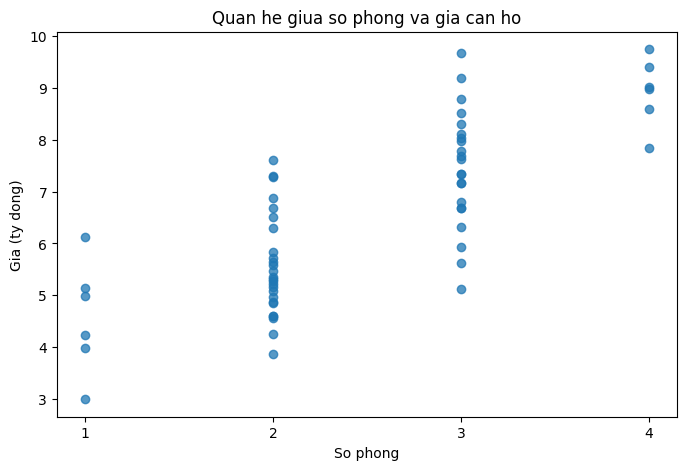

Nhan xet: Can ho co nhieu phong thuong co gia cao hon, nhung cac nhom van chong lan nen so phong khong giai thich toan bo bien dong cua gia.


In [10]:
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
Path("figures").mkdir(exist_ok=True)

plt.figure(figsize=(8, 5))
plt.scatter(df["so_phong"], df["gia"], alpha=0.75)
plt.xlabel("So phong")
plt.ylabel("Gia (ty dong)")
plt.title("Quan he giua so phong va gia can ho")
plt.xticks(sorted(df["so_phong"].unique()))
plt.savefig("figures/bai2.png", dpi=150, bbox_inches="tight")
plt.show()

print("Nhan xet: Can ho co nhieu phong thuong co gia cao hon, nhung cac nhom van chong lan nen so phong khong giai thich toan bo bien dong cua gia.")

### Bài tập 3 - Đổi biến đầu vào sang tuổi nhà

Dùng công thức bình phương tối thiểu với `tuoi_nha` là biến đầu vào và `gia` là biến cần dự đoán.

In [11]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x = df["tuoi_nha"].to_numpy()
y = df["gia"].to_numpy()

x_tb = x.mean()
y_tb = y.mean()
w_tuoi = ((x - x_tb) * (y - y_tb)).sum() / ((x - x_tb) ** 2).sum()
b_tuoi = y_tb - w_tuoi * x_tb

print(f"He so goc  w = {w_tuoi:.6f}")
print(f"He so chan b = {b_tuoi:.6f}")
print("Nhan xet: w am, nghia la tuoi nha tang them mot nam thi gia du doan co xu huong giam. Tuy nhien cac diem phan tan manh, nen dau am chua du de ket luan moi quan he la chat.")

He so goc  w = -0.037858
He so chan b = 6.983593
Nhan xet: w am, nghia la tuoi nha tang them mot nam thi gia du doan co xu huong giam. Tuy nhien cac diem phan tan manh, nen dau am chua du de ket luan moi quan he la chat.


### Bài tập 4 - Thêm số phòng vào mô hình

So sánh mô hình dùng riêng diện tích với mô hình dùng cả diện tích và số phòng trên cùng cách chia dữ liệu.

In [12]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split

df = pd.read_csv("data/gia_nha.csv")
y = df["gia"]

def tinh_r2(cac_cot):
    X = df[cac_cot]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )
    mo_hinh = LinearRegression()
    mo_hinh.fit(X_train, y_train)
    return r2_score(y_test, mo_hinh.predict(X_test))

r2_mot_bien = tinh_r2(["dien_tich"])
r2_hai_bien = tinh_r2(["dien_tich", "so_phong"])

print(f"R2 mo hinh mot bien: {r2_mot_bien:.4f}")
print(f"R2 mo hinh hai bien: {r2_hai_bien:.4f}")
print("Nhan xet: Them so phong lam R2 tang tu 0.9622 len 0.9698. Muc tang co that nhung khong lon, vi so phong co nhieu thong tin trung lap voi dien tich.")

R2 mo hinh mot bien: 0.9622
R2 mo hinh hai bien: 0.9698
Nhan xet: Them so phong lam R2 tang tu 0.9622 len 0.9698. Muc tang co that nhung khong lon, vi so phong co nhieu thong tin trung lap voi dien tich.


### Bài tập 5 - Thử hai tốc độ học khác

Giữ nguyên 200 vòng lặp và so sánh tốc độ học 0.001 với 1.02. Bảng cũng bổ sung các mốc 0.1, 0.5 và 0.9 để đối chiếu.

In [13]:
import numpy as np
import pandas as pd

df = pd.read_csv("data/gia_nha.csv")
x_goc = df["dien_tich"].to_numpy()
y = df["gia"].to_numpy()
x = (x_goc - x_goc.mean()) / x_goc.std()

def mse_sau_200_vong(toc_do_hoc):
    w, b = 0.0, 0.0
    n = len(x)
    for _ in range(200):
        chenh_lech = w * x + b - y
        grad_w = (2 / n) * (chenh_lech * x).sum()
        grad_b = (2 / n) * chenh_lech.sum()
        w -= toc_do_hoc * grad_w
        b -= toc_do_hoc * grad_b
    return ((w * x + b - y) ** 2).mean()

toc_do_thu = [0.001, 0.1, 0.5, 0.9, 1.02]
ket_qua = pd.DataFrame({
    "toc_do_hoc": toc_do_thu,
    "MSE_vong_200": [mse_sau_200_vong(lr) for lr in toc_do_thu],
})
display(ket_qua)

print("Nhan xet: 0.001 qua nho nen sau 200 vong van chua den day. Cac muc 0.1, 0.5 va 0.9 hoi tu. Muc 1.02 qua lon, lien tuc nhay vuot qua day va lam MSE tang rat manh.")

,toc_do_hoc,MSE_vong_200
0,0.001,2.021752e+01
1,0.100,1.790251e-01
2,0.500,1.790251e-01
3,0.900,1.790251e-01
4,1.020,2.903918e+08


Nhan xet: 0.001 qua nho nen sau 200 vong van chua den day. Cac muc 0.1, 0.5 va 0.9 hoi tu. Muc 1.02 qua lon, lien tuc nhay vuot qua day va lam MSE tang rat manh.


### Bài tập 6 - Viết hàm dự đoán có cảnh báo

Hàm dùng lại hệ số của mô hình một biến và cảnh báo khi diện tích nằm ngoài khoảng dữ liệu huấn luyện từ 35.5 đến 117.5 m².

In [14]:
w = 0.078367
b = 0.401752

def du_doan_gia(dien_tich):
    if dien_tich < 35.5 or dien_tich > 117.5:
        print(f"Canh bao: {dien_tich} m2 nam ngoai khoang du lieu huan luyen.")
    return w * dien_tich + b

for dien_tich in [60, 80, 200]:
    gia_du_doan = du_doan_gia(dien_tich)
    print(f"Can {dien_tich} m2 -> du doan {gia_du_doan:.3f} ty dong")

Can 60 m2 -> du doan 5.104 ty dong
Can 80 m2 -> du doan 6.671 ty dong
Canh bao: 200 m2 nam ngoai khoang du lieu huan luyen.
Can 200 m2 -> du doan 16.075 ty dong


## Kết luận

- Mô hình một biến học được `w = 0.078367` và `b = 0.401752`.
- Trên tập kiểm tra, mô hình một biến đạt `R² = 0.9622`.
- Thêm số phòng làm `R²` tăng lên khoảng `0.9698`; dùng ba biến đạt khoảng `0.9761`.
- Gradient descent chỉ hoạt động ổn định khi tốc độ học phù hợp.